In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit, train_test_split
from tqdm import tqdm
import glob
import matplotlib.pyplot as plt
import copy
import random
from collections import defaultdict, Counter

from sklearn.cluster import KMeans
from sklearn.decomposition import KernelPCA
from utils import RandomForestClassifierUnc, XGBEnsemble
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.base import clone

sns.set_style("whitegrid")

import matplotlib

# set font size to 16
matplotlib.rcParams.update({"font.size": 16})

SEED = 4

In [2]:
def initial_split(df_dropped):
    # define train set and test set for each 
    X_train_files = []
    X_test_files = []
    y_train_files = []
    y_test_files = []

    X_file = (df_dropped.drop(["Label", "task_id"], axis=1).to_numpy())
    y_file = df_dropped["Label"].to_numpy()

    X_train, X_test, y_train, y_test = train_test_split(
        X_file, y_file, test_size=0.2, stratify=y_file)

    X_train_files.append(X_train)
    X_test_files.append(X_test)
    y_train_files.append(y_train)
    y_test_files.append(y_test)
        
    return X_train_files, X_test_files, y_train_files, y_test_files


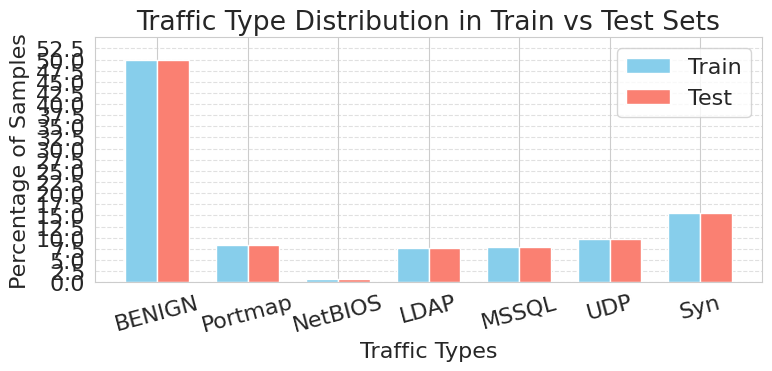

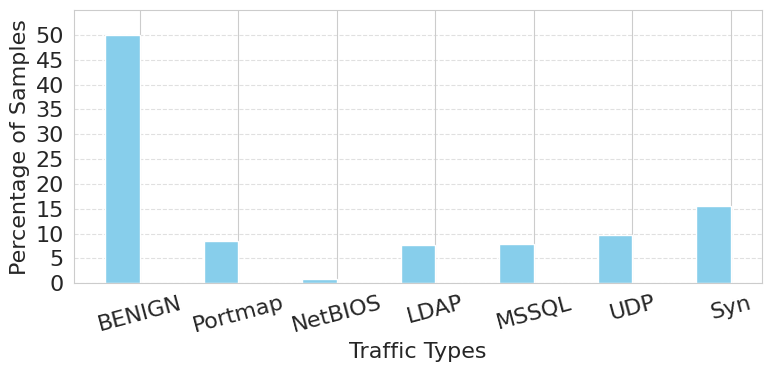

In [4]:
n_runs = 1
df_dropped = pd.read_csv("../CIC_dfdropped/03-11/df_dropped_3000.csv")


#all_accuracy_ent = []
all_accuracy_qbc = []
benchmark_all = []

percentages_dict = defaultdict(lambda: defaultdict(list))
percentages_dict_all = defaultdict(lambda: defaultdict(list))

all_labels = ["BENIGN", "Portmap", "NetBIOS", "LDAP", "MSSQL", "UDP", "Syn"]
counts = Counter(df_dropped["Label"])
total = sum(counts.values())
percentages_all = [(counts.get(label, 0) / total) * 100 if total > 0 else 0.0 for label in all_labels]

  
X_train_files, X_test_files, y_train_files, y_test_files = initial_split(df_dropped)

all_labels = ["BENIGN", "Portmap", "NetBIOS", "LDAP", "MSSQL", "UDP", "Syn"]
y_train_files = y_train_files[0]
y_test_files = y_test_files[0]

counts = Counter(y_train_files)
total = sum(counts.values())
percentages_train = [(counts.get(label, 0) / total) * 100 if total > 0 else 0.0 for label in all_labels]
 
counts = Counter(y_test_files)
total = sum(counts.values())
percentages_test = [(counts.get(label, 0) / total) * 100 if total > 0 else 0.0 for label in all_labels]


# Plot Malicious and Benign Sample Percentages
# Grouped as: [ [Benign%, Malicious%], ... ]
methods = ["Predict Proba (single)", "Predict Proba (batch)", "Random", "KU (single)", 
           "KU (batch)", "QBC (single)"]
categories = ["Benign","Portmap", "NetBIOS", "LDAP", "MSSQL", "UDP", "Syn"]



x = np.arange(len(all_labels))  # label locations
width = 0.35  # bar width

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, percentages_train, width, label="Train", color="skyblue")
plt.bar(x + width/2, percentages_test, width, label="Test", color="salmon")

plt.xlabel("Traffic Types")
plt.ylabel("Percentage of Samples")
plt.title("Traffic Type Distribution in Train vs Test Sets")
plt.xticks(x, all_labels, rotation=15)
plt.yticks(np.arange(0, max(max(percentages_train), max(percentages_test)) + 5, 2.5))
plt.ylim(0, max(max(percentages_train), max(percentages_test)) + 5)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


x = np.arange(len(all_labels))  # label locations
width = 0.35  # bar width

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, percentages_all, width, color="skyblue")

plt.xlabel("Traffic Types")
plt.ylabel("Percentage of Samples")
#plt.title("Traffic Type Distribution in Entire Dataset")
plt.xticks(x, all_labels, rotation=15)
plt.yticks(np.arange(0, max(max(percentages_train), max(percentages_test)) + 3, 5))
plt.ylim(0, max(max(percentages_train), max(percentages_test)) + 5)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(f"./thesis_benign/original_distribution.pdf", bbox_inches='tight')
plt.show()
